In [ ]:
import torch 
import matplotlib.pyplot as plt
# runs on CPU

# Hyperparameters
n = 5
m = 20
p = 500
sig = 0.1
K = 20
itermax = 1000
#nu = [(i/K)**2 for i in range(1,K+1)]  # weights for the loss
# logspaced weights
nu = torch.logspace(-6, 1, K)
#nu = torch.zeros(K)+0.01
#nu[K-1] = 1.0

# define training data
torch.manual_seed(2)
mu = 50*torch.rand(n, 1)
H = torch.randn(n, p) + mu  # H are generated around a true value mu
W = torch.rand(m, n)
Y = W@H + sig*torch.randn(m, p)

# define trainable parameters
Ah = torch.ones(n,K, requires_grad=True)

# define loss function
def loss_fn(Y, W, H):
    return torch.norm(Y - W@H)**2

# define MU updates
def MU_update(W, Y, Xinit, itermax=1000, Xgt=None):
    X = Xinit.clone().detach()
    WtW = W.T@W
    WtY = W.T@Y
    loss = [loss_fn(Y, W, X)]
    sup_loss = []
    for i in range(itermax):
        X = X*WtY/(WtW@X)
        loss.append(loss_fn(Y, W, X))  # can be optimized using stored quantities
        if Xgt is not None:
            sup_loss.append(torch.norm(X - Xgt)**2)
    return X, loss, sup_loss

# define unrolled MU updates
def NALMU(W, Y, Xinit, Ah, itermax=25, Xgt=None):
    X = Xinit.clone().detach()
    loss = [loss_fn(Y, W, X)]
    WtW = W.T@W
    WtY = W.T@Y
    Xs = []
    sup_loss = []
    for i in range(itermax):
        XAh = (X.T*Ah[:,i]).T
        X = XAh*WtY/(WtW@X)
        Xs.append(X)
        loss.append(loss_fn(Y, W, X))  # can be optimized using stored quantities
        if Xgt is not None:
            supl = torch.norm(X - Xgt)**2
            sup_loss.append(supl.detach().numpy())
    return X, Xs, loss, sup_loss

# define optimizer
optimizer = torch.optim.Adam([Ah], lr=1e-2)   # using the Adam optimizer for simplicity

# Training
for epoch in range(500):
    optimizer.zero_grad()
    Hinit = torch.ones(n, p)
    H_est, Hs, _, _ = NALMU(W, Y, Hinit, Ah, itermax=K)
    loss = sum([nu[i]*torch.norm(Hs[i] - H)**2 for i in range(K)])  # weighted loss
    #loss = torch.norm(Hs[K-1] - H)  # weighted loss
    loss.backward()
    optimizer.step()
    #Ah.data.clamp_(0)  # ensure nonnegativity
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')
      

Epoch 0, Loss: 102606.2578125
Epoch 10, Loss: 54040.0234375
Epoch 20, Loss: 19632.412109375
Epoch 30, Loss: 9117.84765625
Epoch 40, Loss: 4661.9892578125
Epoch 50, Loss: 4689.87890625
Epoch 60, Loss: 4272.0556640625
Epoch 70, Loss: 3969.502197265625
Epoch 80, Loss: 3957.6826171875
Epoch 90, Loss: 3910.64599609375
Epoch 100, Loss: 3904.442138671875
Epoch 110, Loss: 3898.886962890625
Epoch 120, Loss: 3894.0341796875
Epoch 130, Loss: 3890.4384765625
Epoch 140, Loss: 3887.63330078125
Epoch 150, Loss: 3885.312255859375
Epoch 160, Loss: 3883.261474609375
Epoch 170, Loss: 3881.423583984375
Epoch 180, Loss: 3879.769775390625
Epoch 190, Loss: 3878.26220703125
Epoch 200, Loss: 3876.884765625
Epoch 210, Loss: 3875.613037109375
Epoch 220, Loss: 3874.44677734375
Epoch 230, Loss: 3873.359130859375
Epoch 240, Loss: 3872.348876953125
Epoch 250, Loss: 3871.398193359375
Epoch 260, Loss: 3870.51123046875
Epoch 270, Loss: 3869.678466796875
Epoch 280, Loss: 3868.88623046875
Epoch 290, Loss: 3868.1333007812

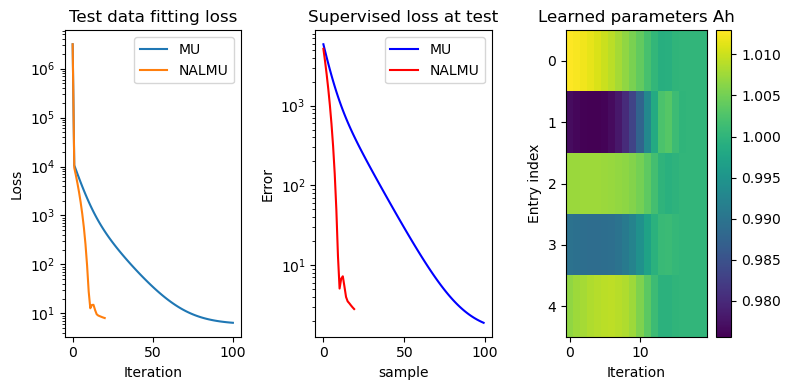

In [127]:
# Test time!
p_test = 40
Htest = mu+torch.rand(n, p_test)
Ytest = W@Htest + sig*torch.randn(m, p_test)

H_NALMU, _, loss_NALMU, sup_loss_NALMU = NALMU(W, Ytest, torch.ones(n, p_test), Ah, itermax=K, Xgt=Htest)
H_MU, loss_MU, sup_loss_MU = MU_update(W, Ytest, torch.ones(n, p_test), itermax=5*K, Xgt=Htest)

# PLotting errors for MU and showing line with NALMU error after K iterations
fig, ax = plt.subplots(1,3, figsize=(8,4))
ax[0].semilogy(loss_MU)
ax[0].semilogy([loss_NALMU[i].detach().numpy() for i in range(len(loss_NALMU))])
ax[0].set_title('Test data fitting loss')
ax[0].set_xlabel('Iteration')
ax[0].set_ylabel('Loss')
ax[0].legend(['MU', 'NALMU'])

# Plot error bars for each sample
ax[1].semilogy(sup_loss_MU, 'b-')
ax[1].semilogy(sup_loss_NALMU, 'r-')
ax[1].set_title('Supervised loss at test')
ax[1].set_xlabel('sample')
ax[1].set_ylabel('Error')
ax[1].legend(['MU', 'NALMU'])

# Showing matrix Ah as an image
ax[2].imshow(Ah.detach().numpy(), aspect='auto')
ax[2].set_title('Learned parameters Ah')
ax[2].set_xlabel('Iteration')
ax[2].set_ylabel('Entry index')
#colorbar
ax[2].figure.colorbar(ax[2].images[0], ax=ax[2])
plt.tight_layout()
plt.show()

In [111]:
nu

tensor([1.0000e-06, 1.7783e-06, 3.1623e-06, 5.6234e-06, 1.0000e-05, 1.7783e-05,
        3.1623e-05, 5.6234e-05, 1.0000e-04, 1.7783e-04, 3.1623e-04, 5.6234e-04,
        1.0000e-03, 1.7783e-03, 3.1623e-03, 5.6234e-03, 1.0000e-02, 1.7783e-02,
        3.1623e-02, 5.6234e-02, 1.0000e-01, 1.7783e-01, 3.1623e-01, 5.6234e-01,
        1.0000e+00])